<a href="https://colab.research.google.com/github/Vaisshhh55/Devopslab8/blob/main/kaggle.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

print(train.shape)
print(test.shape)

train.head()

(266192, 15)
(295753, 14)


,id,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
0,0,unhealthy,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,veg,high,average,sedentary,yes,female
1,1,at-risk,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,non-veg,low,average,moderate,yes,other
2,2,unhealthy,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,veg,high,poor,active,yes,male
3,3,unhealthy,4.70,77.2,23.13,2630.0,7174.0,59.9,2.02,veg,high,average,active,occasional,female
4,4,at-risk,7.23,73.4,28.44,2560.0,6584.0,46.0,2.25,veg,NaN,average,sedentary,NaN,male


In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 266192 entries, 0 to 266191
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       266192 non-null  int64  
 1   health_condition         266192 non-null  object 
 2   sleep_duration           236820 non-null  float64
 3   heart_rate               263131 non-null  float64
 4   bmi                      260805 non-null  float64
 5   calorie_expenditure      245747 non-null  float64
 6   step_count               260877 non-null  float64
 7   exercise_duration        263552 non-null  float64
 8   water_intake             249377 non-null  float64
 9   diet_type                263521 non-null  object 
 10  stress_level             234180 non-null  object 
 11  sleep_quality            243708 non-null  object 
 12  physical_activity_level  251964 non-null  object 
 13  smoking_alcohol          255108 non-null  object 
 14  gend

In [ ]:
train.isnull().sum()

,0
id,0
health_condition,0
sleep_duration,29372
heart_rate,3061
bmi,5387
calorie_expenditure,20445
step_count,5315
exercise_duration,2640
water_intake,16815
diet_type,2671


In [ ]:
train["health_condition"].value_counts()

,count
health_condition,
at-risk,228496
unhealthy,22217
fit,15479


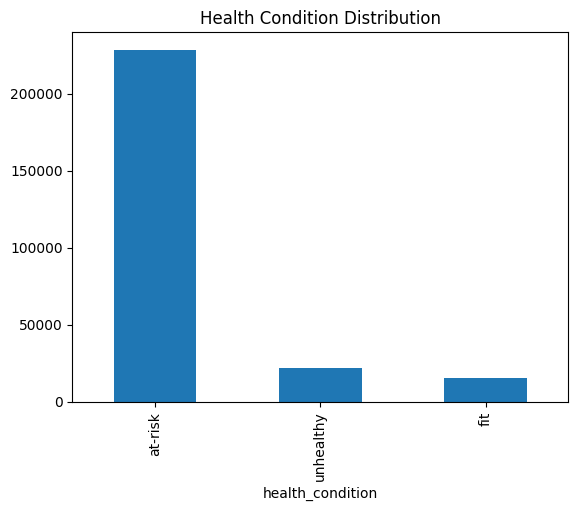

In [ ]:
import matplotlib.pyplot as plt

train["health_condition"].value_counts().plot(kind="bar")
plt.title("Health Condition Distribution")
plt.show()

In [ ]:
train.describe()

,id,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake
count,266192.000000,236820.000000,263131.000000,260805.000000,245747.000000,260877.000000,263552.000000,249377.000000
mean,133095.500000,6.994026,75.099448,22.985759,2226.408086,8622.891911,38.787712,2.187364
std,76843.155765,1.217671,8.178774,2.480150,347.785666,3933.030059,14.747461,0.518554
min,0.000000,3.000000,50.000000,16.000000,1201.000000,1002.000000,0.000000,0.500000
25%,66547.750000,6.150000,69.400000,21.320000,2053.000000,5391.000000,29.200000,1.840000
50%,133095.500000,6.990000,75.100000,23.000000,2241.000000,8863.000000,39.400000,2.170000
75%,199643.250000,7.820000,80.700000,24.660000,2457.000000,12120.000000,49.400000,2.500000
max,266191.000000,10.000000,106.700000,34.820000,3580.000000,14999.000000,99.800000,4.720000


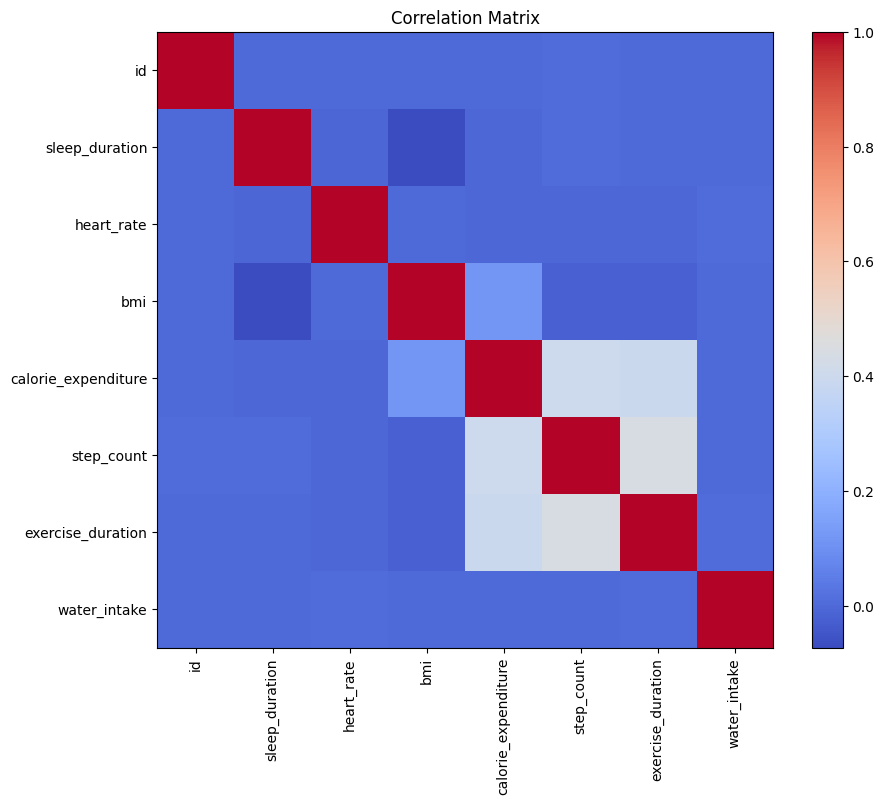

In [ ]:
import matplotlib.pyplot as plt

corr = train.select_dtypes(include="number").corr()

plt.figure(figsize=(10,8))
plt.imshow(corr, cmap="coolwarm")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Matrix")
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

# Features and target
X = train.drop(["health_condition", "id"], axis=1)
y = train["health_condition"]

# Categorical and numerical columns
cat_cols = X.select_dtypes(include="object").columns
num_cols = X.select_dtypes(exclude="object").columns

# Numerical preprocessing
num_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

# Categorical preprocessing
cat_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# Combine preprocessing
preprocessor = ColumnTransformer([
    ("num", num_transformer, num_cols),
    ("cat", cat_transformer, cat_cols)
])

# Split data
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import balanced_accuracy_score

model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ))
])

model.fit(X_train, y_train)

pred = model.predict(X_valid)

score = balanced_accuracy_score(y_valid, pred)

print("Balanced Accuracy:", score)

Balanced Accuracy: 0.8556798324093262


In [ ]:
# Remove id column from test data
X_test = test.drop("id", axis=1)

# Predict
test_predictions = model.predict(X_test)

# Create submission file
submission = pd.DataFrame({
    "id": test["id"],
    "health_condition": test_predictions
})

# Save CSV
submission.to_csv("submission.csv", index=False)

print(submission.head())


       id health_condition
0  690088        unhealthy
1  690089          at-risk
2  690090          at-risk
3  690091          at-risk
4  690092        unhealthy


In [ ]:
submission.to_csv("submission.csv", index=False)

In [ ]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.7 MB/s eta 0:00:00


In [ ]:
X_train.dtypes

,0
sleep_duration,float64
heart_rate,float64
bmi,float64
calorie_expenditure,float64
step_count,float64
exercise_duration,float64
water_intake,float64
diet_type,object
stress_level,object
sleep_quality,object


In [ ]:
X_train.select_dtypes(include='object').columns

Index(['diet_type', 'stress_level', 'sleep_quality', 'physical_activity_level',
       'smoking_alcohol', 'gender'],
      dtype='object')

In [ ]:
print(X_train.dtypes)

sleep_duration             float64
heart_rate                 float64
bmi                        float64
calorie_expenditure        float64
step_count                 float64
exercise_duration          float64
water_intake               float64
diet_type                   object
stress_level                object
sleep_quality               object
physical_activity_level     object
smoking_alcohol             object
gender                      object
dtype: object


In [ ]:
print(X_train.head())

        sleep_duration  heart_rate    bmi  calorie_expenditure  step_count  \
243554            4.87        72.6  21.17               1587.0      3489.0   
207487            5.63        76.1  23.76               2102.0      3844.0   
68146             6.59        77.2  24.29               2460.0      4566.0   
139188            6.42        74.7  21.38               3058.0     13156.0   
43139             6.65        83.2  21.47               2356.0      4226.0   

        exercise_duration  water_intake diet_type stress_level sleep_quality  \
243554               32.7          1.66  balanced          low          poor   
207487               34.8          1.74  balanced       medium          good   
68146                28.0          1.96       veg          low          poor   
139188               62.7          1.87       veg          NaN          good   
43139                38.3          2.48  balanced          low           NaN   

       physical_activity_level smoking_alcohol gen

In [ ]:
from catboost import CatBoostClassifier
from sklearn.metrics import balanced_accuracy_score

# Find categorical columns
cat_features = X_train.select_dtypes(include=['object']).columns.tolist()

model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.1,
    depth=8,
    loss_function='MultiClass',
    random_seed=42,
    verbose=100
)
# Fill missing values in categorical columns
for col in cat_features:
    X_train[col] = X_train[col].fillna("Unknown").astype(str)
    X_valid[col] = X_valid[col].fillna("Unknown").astype(str)

# Fill missing values in numerical columns
num_cols = X_train.select_dtypes(exclude=['object']).columns

for col in num_cols:
    median = X_train[col].median()
    X_train[col] = X_train[col].fillna(median)
    X_valid[col] = X_valid[col].fillna(median)



In [ ]:
model.fit(
    X_train,
    y_train,
    cat_features=cat_features
)

pred = model.predict(X_valid)

score = balanced_accuracy_score(y_valid, pred)

print("Balanced Accuracy:", score)

0:	learn: 0.9381055	total: 1.67s	remaining: 13m 54s
100:	learn: 0.0914538	total: 3m 18s	remaining: 13m 4s
200:	learn: 0.0872693	total: 6m 34s	remaining: 9m 47s
300:	learn: 0.0836166	total: 10m	remaining: 6m 36s
400:	learn: 0.0805794	total: 13m 23s	remaining: 3m 18s
499:	learn: 0.0775015	total: 16m 43s	remaining: 0us
Balanced Accuracy: 0.8779554547215529


In [ ]:
# Prepare test data the same way as training data
X_test = test.drop("id", axis=1)

# Fill missing values
for col in cat_features:
    X_test[col] = X_test[col].fillna("Unknown").astype(str)

num_cols = X_test.select_dtypes(exclude=['object']).columns

for col in num_cols:
    median = X_train[col].median()   # Use training median
    X_test[col] = X_test[col].fillna(median)

# Predict
test_predictions = model.predict(X_test)

# Create submission file
submission = pd.DataFrame({
    "id": test["id"],
    "health_condition": test_predictions.flatten()
})

submission.to_csv("submission_catboost.csv", index=False)

print(submission.head())


       id health_condition
0  690088        unhealthy
1  690089          at-risk
2  690090          at-risk
3  690091          at-risk
4  690092        unhealthy
